# DQN Training Results

Connect to Google Colab CPU or directly login in the browser.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 · Load training logs

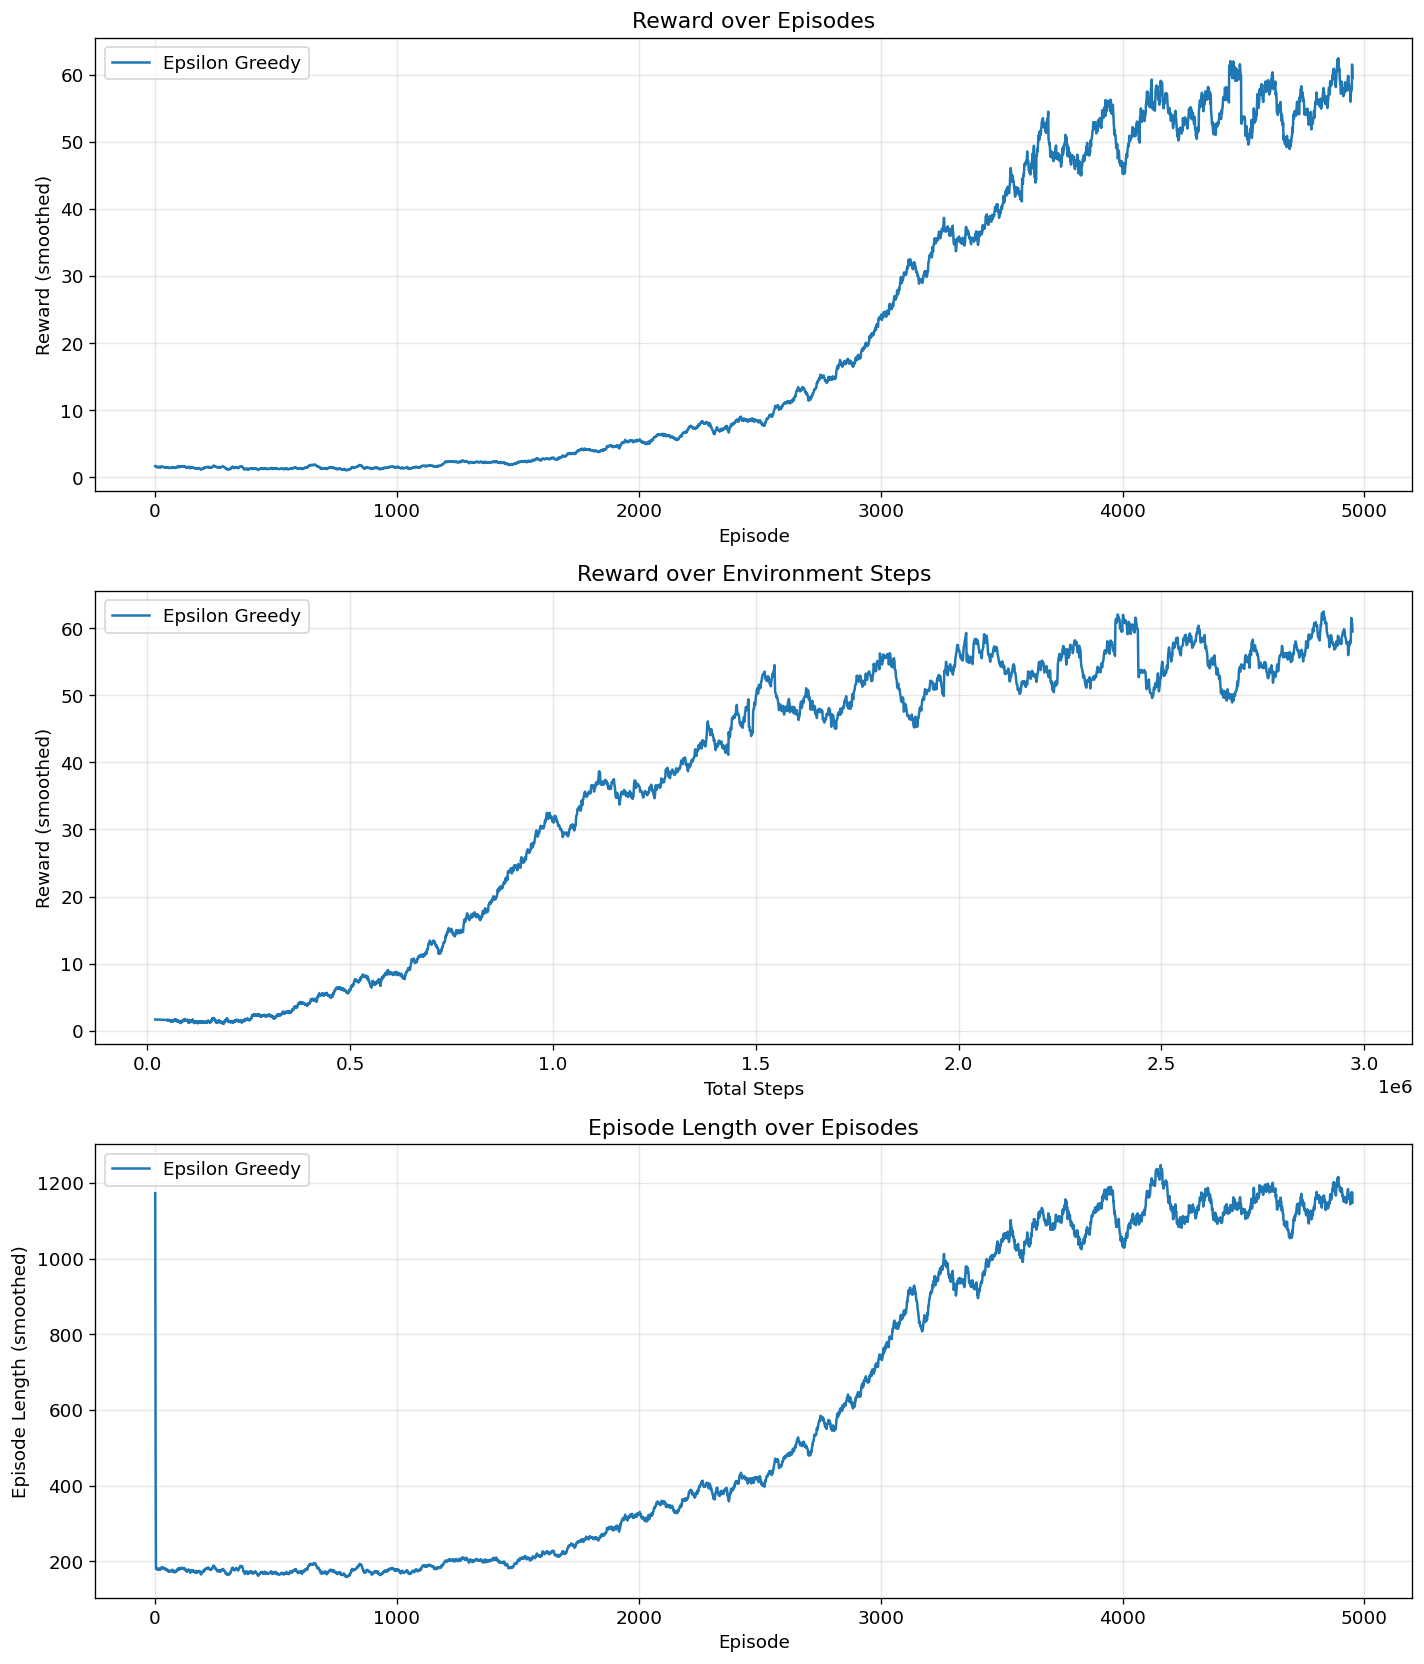

In [5]:
import glob
import json
import os

import matplotlib.pyplot as plt
import numpy as np

EPSILON_GREEDY_DIR = '/content/drive/MyDrive/Exploration/EpsilonGreedy/'
log_files = sorted(glob.glob(os.path.join(EPSILON_GREEDY_DIR, '*.jsonl')))


def load_log(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    episodes    = [r["episode"]     for r in records]
    total_steps = [r["total_steps"] for r in records]
    rewards     = [r["reward"]      for r in records]
    ep_lens     = [r["ep_len"]      for r in records]
    return episodes, total_steps, rewards, ep_lens


def smooth(values, window=50):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


fig, axes = plt.subplots(3, 1, figsize=(12, 14))
ax_rew_ep, ax_rew_step, ax_len_ep = axes

for path in log_files:
    label = "Epsilon Greedy"
    episodes, total_steps, rewards, ep_lens = load_log(path)

    s_rewards  = smooth(rewards)
    s_ep_lens  = smooth(ep_lens)
    ep_trim    = episodes[:len(s_rewards)]
    step_trim  = total_steps[:len(s_rewards)]
    ep_len_trim = episodes[:len(s_ep_lens)]

    # reward over episodes
    ax_rew_ep.plot(ep_trim, s_rewards, label=label)

    # reward over steps
    ax_rew_step.plot(step_trim, s_rewards, label=label)

    # episode length over episodes
    ax_len_ep.plot(ep_len_trim, s_ep_lens, label=label)

ax_rew_ep.set_title("Reward over Episodes")
ax_rew_ep.set_xlabel("Episode")
ax_rew_ep.set_ylabel("Reward (smoothed)")
ax_rew_ep.legend()
ax_rew_ep.grid(True, alpha=0.3)

ax_rew_step.set_title("Reward over Environment Steps")
ax_rew_step.set_xlabel("Total Steps")
ax_rew_step.set_ylabel("Reward (smoothed)")
ax_rew_step.legend()
ax_rew_step.grid(True, alpha=0.3)

ax_len_ep.set_title("Episode Length over Episodes")
ax_len_ep.set_xlabel("Episode")
ax_len_ep.set_ylabel("Episode Length (smoothed)")
ax_len_ep.legend()
ax_len_ep.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()